In [10]:
import numpy as np
from typing import Callable, Optional, List, Self
from numpy.typing import NDArray
import matplotlib.pyplot as plt

In [2]:
# want to generate data as royi did it

numSamples = 200
noiseStd = 0.01

gridNioseStd = 0.05
numGridPts = 500


In [30]:
from DataVisualization import PlotRegressionData

In [5]:
def f( vX: NDArray ):
    
    return 5 * np.exp(-vX) * np.sin(10 * vX + 0.5) * (1 + 10 * (vX > 2) * (vX - 2)) + 1

In [49]:
vX = 4  * np.sort(np.random.rand(numSamples))
vY = f(vX) + noiseStd * np.random.rand(numSamples)

print(vX.shape)
print(vY.shape)

(200,)
(200,)


<Axes: xlabel='${x}_{1}$'>

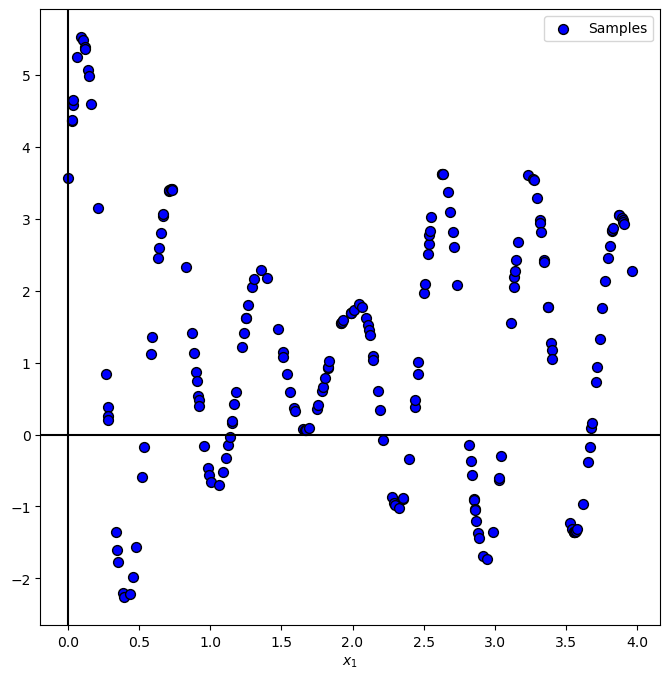

In [31]:
PlotRegressionData(vX, vY)

In [41]:
# Defining of the Kernels

def UniformKernel(vU:NDArray) -> NDArray:
    return 1.0 * (np.abs(vU) < 0.5)

def TriangularKernel(vU:NDArray) -> NDArray:
    return (np.abs(vU) < 1) * (1 - np.abs(vU))

def GaussianKernel( vU:NDArray) -> NDArray:
    return np.exp(-0.5 * np.square(vU))

def CosineKernel( vU: NDArray ) -> NDArray:
    return (np.abs(vU) < 1) * (1 + np.cos(np.pi * vU))

lKernels = [('Uniform', UniformKernel), ('Triangular', TriangularKernel), ('Gaussian', GaussianKernel), ('Cosine', CosineKernel)]

In [40]:
lKernels = [('Cosine', CosineKernel), ('Gaussian', GaussianKernel), ('Triangular', TriangularKernel), ('Uniform', UniformKernel)]

NameError: name 'numGridPts' is not defined

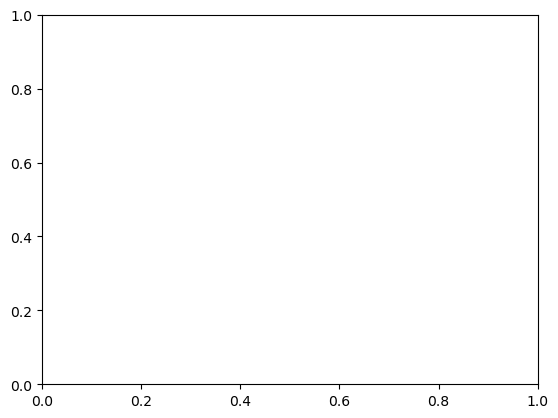

In [18]:
hF, hA = plt.subplots()

vX0 = np.linspace(-4, 4, numGridPts)

for ii, (kernelLabel, hKernel) in enumerate(lKernels):
    hA.scatter(vX0, hKernel(vX0), s=6, label = kernelLabel)
    hA.plot(vX0, hKernel(vX0), lw = 1)


hA.set_xlabel('x')
hA.set_ylabel('y')
hA.set_title('The Kernels')
hA.legend()
hA.grid();


In [ ]:
# lets implement one shot for specific h and for specific kernel function for the database

In [19]:
def ApplyKenel(hKernel, paramH, vX, vY, vX0, zeroThr=1e-9):
    mW = hKernel((vX0[:, None] - vX[None, :]) / paramH)
    vK = mW @ vY
    vW = np.sum(mW, axis = 1)
    vI = np.abs(vW) < zeroThr
    vK[vI] = 0
    vW[vI] = 1
    vYPred = vK / vW
    return vYPred

In [20]:
vX0 = np.linspace(-0.2, 4.5, 1000)
vY_pred = ApplyKenel(hKernel= UniformKernel, paramH=0.15, vX=vX, vY=vY, vX0=vX0)

NameError: name 'vX' is not defined

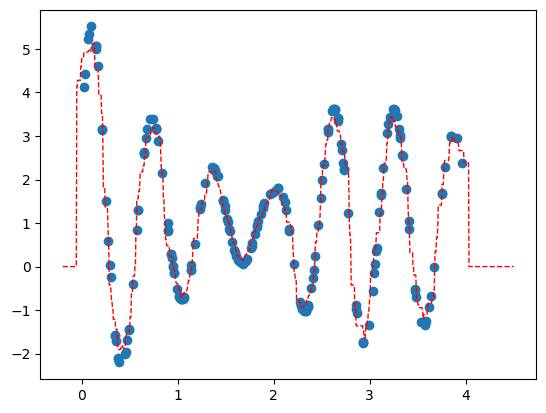

In [61]:
fig, ax = plt.subplots()
ax.scatter(vX, vY)
ax.plot(vX0, vY_pred, color='red', lw =1, linestyle='--')

plt.show()

In [ ]:
# after that i want to uplad boston

In [46]:
import pandas as pd

url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

dfX = df.drop(columns="medv")
dsY = df["medv"]

print(f"The features data shape: {dfX.shape}")
print(f"The labels data shape: {dsY.shape}")

The features data shape: (506, 13)
The labels data shape: (506,)


In [64]:
df.shape

(506, 14)

In [26]:
df.head()

,crim,zn,indus,nox,rm,age,dis,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,222,18.7,396.90,5.33,36.2


In [47]:
#creation of feature and target matrix
mX = dfX.drop(columns=['chas', 'rad']).to_numpy()
vY = dsY.to_numpy()

print(mX.shape)
print(vY.shape)

(506, 11)
(506,)


In [28]:
# now, we want to visualize correlation between coulumns


In [29]:
matrix = df.corr().abs()
matrix

,crim,zn,indus,nox,rm,age,dis,tax,ptratio,b,lstat,medv
crim,1.000000,0.200469,0.406583,0.420972,0.219247,0.352734,0.379670,0.582764,0.289946,0.385064,0.455621,0.388305
zn,0.200469,1.000000,0.533828,0.516604,0.311991,0.569537,0.664408,0.314563,0.391679,0.175520,0.412995,0.360445
indus,0.406583,0.533828,1.000000,0.763651,0.391676,0.644779,0.708027,0.720760,0.383248,0.356977,0.603800,0.483725
nox,0.420972,0.516604,0.763651,1.000000,0.302188,0.731470,0.769230,0.668023,0.188933,0.380051,0.590879,0.427321
rm,0.219247,0.311991,0.391676,0.302188,1.000000,0.240265,0.205246,0.292048,0.355501,0.128069,0.613808,0.695360
age,0.352734,0.569537,0.644779,0.731470,0.240265,1.000000,0.747881,0.506456,0.261515,0.273534,0.602339,0.376955
dis,0.379670,0.664408,0.708027,0.769230,0.205246,0.747881,1.000000,0.534432,0.232471,0.291512,0.496996,0.249929
tax,0.582764,0.314563,0.720760,0.668023,0.292048,0.506456,0.534432,1.000000,0.460853,0.441808,0.543993,0.468536
ptratio,0.289946,0.391679,0.383248,0.188933,0.355501,0.261515,0.232471,0.460853,1.000000,0.177383,0.374044,0.507787
b,0.385064,0.175520,0.356977,0.380051,0.128069,0.273534,0.291512,0.441808,0.177383,1.000000,0.366087,0.333461


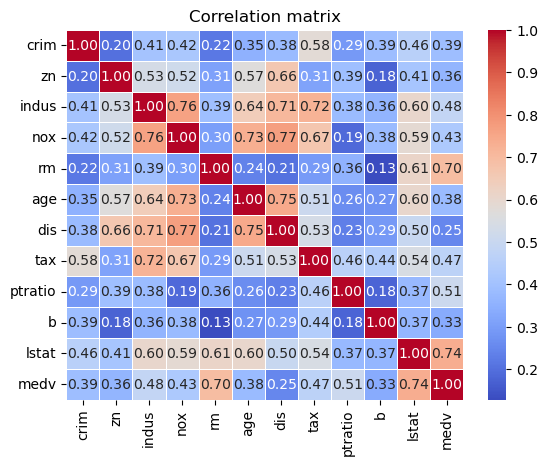

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation matrix")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler




In [ ]:
# Standartization

oStdScaler = StandardScaler()
mX = oStdScaler.fit_transform(mX)


(506, 11)

In [ ]:
# We build a function which apply kernel regression and predict the values of target

def ApplyKernelRegression(hKernel: Callable[[NDArray], NDArray], paramH: float, mX:NDArray, vY: NDArray, mX0:NDArray, metricType: str = 'euclidean', zeroThr:float=1e-9) -> NDArray:

    if paramH <= 0:
        raise ValueError('paramH must be positive')
    mD = sp.spatial.distance.cdist(mX0, mX, metric=metricType) # matrix of disatnces between every row in matrox mX0 to every row in matrix mX
    mW = hKernel(mD / paramH) # calculation of weights with kernel function and paramH (channel width)
    vK = mW @ vY 
    vW = np.sum(mW, axis=1) # Summation of every row for further normalization
    vI = np.abs(vW) < zeroThr # finding of indexes with values which a close to zero, to evoid devision by zero 
    vK[vI] = 0.0 # asigning of zero to indexes which where very close to zero
    vW[vI] = 1.0 # by assigning of value 1 to vW[vI] we devide 0/1 and get zero and by this way avoiding deviding by zero
    vYPred = vK / vW

    return vYPred


In [33]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score
from sklearn.model_selection import cross_val_predict, KFold

In [34]:
lH = list(np.linspace(0.1, 5, 50))
lKernelType = [('Cosine', CosineKernel), ('Gaussian', GaussianKernel), ('Triangular', TriangularKernel), ('Uniform', UniformKernel)]

In [50]:
# Creation of SciKit Estimator

class KernelRegressor(RegressorMixin, BaseEstimator):
    def __init__(self, kernelType: str = 'Gaussian', paramH: Optional[float] = None, metricType: str = 'euclidean', lKernels: List = lKernels):
        self.kernelType = kernelType
        hKernel = None
        for tKernel in lKernels:
            if tKernel[0] == kernelType:
                hKernel = tKernel[1]
                break
        if hKernel is not None:
            self.hKernel = hKernel
        else:
            raise ValueError(f'The kernel in kernelType = {kernelType} is not in lKernels')
        self.paramH = paramH
        self.metricType = metricType
        self.lKernels = lKernels

    def fit(self, mX:NDArray, vY:NDArray) -> Self:
        
        if np.ndim(mX) != 2:
            raise ValueError(f'The input mX must be an array like of size (n_samples, n_features) !')
        if mX.shape[0] != vY.shape[0]:
            raise ValueError(f'vY must be vector with target values for n_sampes in mX')
        
        numSamples = mX.shape[0]
        if self.paramH is None:
            σ = np.sqrt(np.sum(np.sqaure(mX - np.mean(mX, axis = 0))))
            self.paramH = 1.06 * σ * (numSamples ** (-0.2))
        self.mXd = mX.copy()
        self.vYd = vY.copy()

        return self
    
    def predict(self, mX:NDArray) -> NDArray:
        if np.ndim(mX) != 2:
            raise ValueError(f'The input mX must be an array like of size (n_samples, n_features) !')
        if mX.shape[0] != vY.shape[0]:
            raise ValueError(f'vY must be vector with target values for n_sampes in mX')
        
        return ApplyKernelRegression(hKernel=self.hKernel, paramH=self.paramH, mX=self.mXd, vY=self.vYd, mX0=mX, metricType=self.metricType)
    
    def score(self, mX: NDArray, vY: NDArray) -> float:
        # return R2 as a score
        if mX.shape[0] != vY.shape[0]:
            raise ValueError(f'vY must be vector with target values for n_sampes in mX')
        
        vYPred = self.predic(mX)
        valR2 = r2_score(vY, vYPred)
        return valR2
       


In [38]:

lKernelType = ['Cosine', 'Gaussian', 'Triangular', 'Uniform']

In [44]:
# creating of data frame to further fill it with results

numComb = len(lKernelType) * len(lH)
dData = {
    'Kernel Type': [],
    'h' : [],
    'R2': [0.0] * numComb
} # creation of dictionary

for ii, kernelType in enumerate(lKernelType):
    for jj, paramH in enumerate(lH):
        dData['Kernel Type'].append(kernelType)
        dData['h'].append(paramH)

dfModelScore = pd.DataFrame(data=dData)
dfModelScore

,Kernel Type,h,R2
0,Cosine,0.1,0.0
1,Cosine,0.2,0.0
2,Cosine,0.3,0.0
3,Cosine,0.4,0.0
4,Cosine,0.5,0.0
...,...,...,...
195,Uniform,4.6,0.0
196,Uniform,4.7,0.0
197,Uniform,4.8,0.0
198,Uniform,4.9,0.0


In [51]:
# Optimize the model

for ii in range(numComb):
    kernelType = dfModelScore.loc[ii, 'Kernel Type']
    paramH = dfModelScore.loc[ii, 'h']

    print(f'Processing model {ii + 1:03d} out of {numComb} with Kernel Type = {kernelType} and h = {paramH}.')

    oKerReg = KernelRegressor(kernelType=kernelType, paramH=paramH)
    vYPred = cross_val_predict(oKerReg, mX, vY, cv = KFold(n_splits=mX.shape[0]))
    scoreR2 = r2_score(vY, vY_pred)
    dfModelScore.loc[ii, 'R2'] = scoreR2
    print(f'Finishing processing model {ii +1} withR2 = {scoreR2}')


Processing model 001 out of 200 with Kernel Type = Cosine and h = 0.1.


ValueError: vY must be vector with target values for n_sampes in mX